Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Accuracy : 0.956140350877193
Precision: 0.958904109589041
Recall : 0.9722222222222222
F1 Score : 0.9655172413793104
ROC AUC : 0.9937169312169312

Confusion Matrix
[[39  3]
 [ 2 70]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



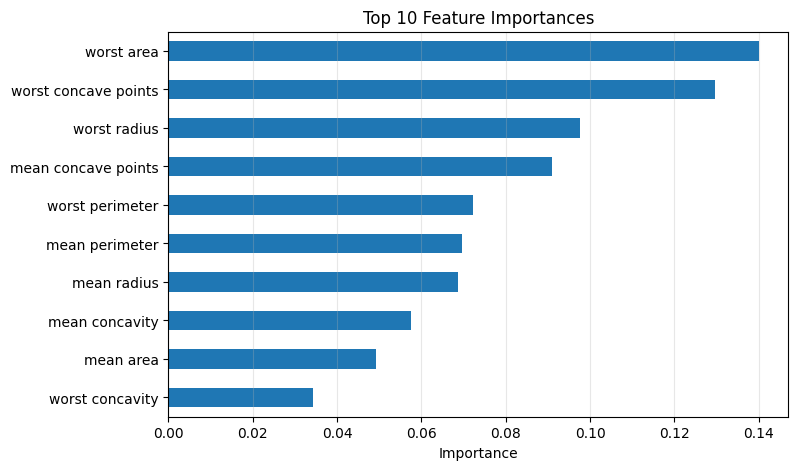

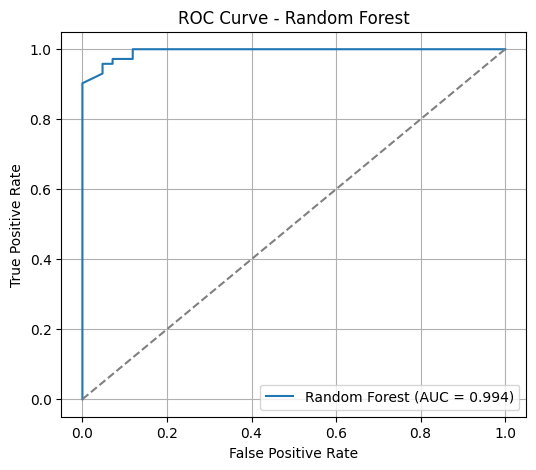

In [1]:
# Step 1: Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Step 2: Load Dataset

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)

y = pd.Series(data.target, name="target")

# Step 3: Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Step 4: Create Random Forest Model

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

# Step 5: Hyperparameter Tuning

param_grid = {
    "n_estimators": [100],
    "max_depth": [None, 10],
    "min_samples_split": [2],
    "min_samples_leaf": [1]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=1
)

grid.fit(X_train, y_train)

print("Best Parameters:")

print(grid.best_params_)

best_rf = grid.best_estimator_

# Step 6: Train Final Model

best_rf.fit(X_train, y_train)

# Step 7: Prediction

y_pred = best_rf.predict(X_test)

y_prob = best_rf.predict_proba(X_test)[:,1]

# Step 8: Evaluation

print("\nAccuracy :", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

print("ROC AUC :", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")

print(cm)

print("\nClassification Report")

print(classification_report(y_test, y_pred))

# Step 9: Feature Importance

importances = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
)

top10 = importances.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

top10[::-1].plot(kind="barh")

plt.xlabel("Importance")

plt.title("Top 10 Feature Importances")

plt.grid(axis="x", alpha=0.3)

plt.show()

# Step 10: ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob):.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend()

plt.grid(True)

plt.show()